In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
from pathlib import Path

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/share/proj failed


In [6]:
ds = xr.open_dataarray('/g/data/er8/users/cd3022/Irradiance-comparisons/era5-himawari/monthly/msdwswrf-era5-himawari_201609.nc')

In [12]:
file_path = Path('/g/data/er8/users/cd3022/Irradiance-comparisons/era5-himawari/monthly')
files = list(file_path.rglob("*.nc"))
ds = xr.open_mfdataset(files, combine='nested', compat='override')

# NO TIME DIMENSION FOR DATASETS TO CONCAT ON

In [17]:
ds

<xarray.Dataset> Size: 33MB
Dimensions:                        (longitude: 2303, latitude: 1795)
Coordinates:
  * longitude                      (longitude) float32 9kB 112.0 112.0 ... 156.3
  * latitude                       (latitude) float32 7kB -44.5 -44.48 ... -10.0
Data variables:
    __xarray_dataarray_variable__  (latitude, longitude) float64 33MB dask.array<chunksize=(1795, 2303), meta=np.ndarray>

In [ ]:
# directory=Path('/g/data/er8/users/cd3022/Irradiance-comparisons/era5-himawari/monthly')
# files = sorted(str(p) for p in directory.rglob("*.nc"))
# ds = xr.open_mfdataset(
#     ds_files,
#     combine='by_coords',
# )

ValueError: not enough values to unpack (expected 2, got 0)

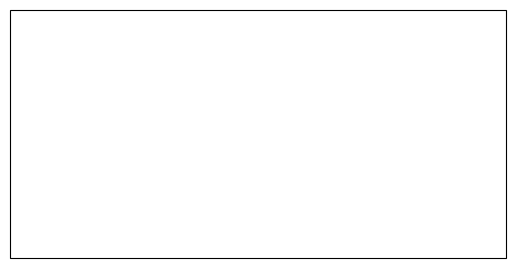

In [14]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})

mesh=ax.pcolormesh(ds.longitude.values,
                   ds.latitude.values,
                   ds.values,
                   cmap='BrBG',
                   transform=ccrs.PlateCarree(),
                   vmin=-300,
                   vmax=300
                  )

ax.coastlines()
cbar = plt.colorbar(mesh,ax=ax,shrink=0.5)
cbar.ax.tick_params(labelsize=5)  # Set the font size for the colorbar ticks
cbar.set_label('Value', fontsize=5) 
 
plt.tight_layout()

plt.show()